<a href="https://colab.research.google.com/github/jjayli/my-data-science/blob/main/notebook/kpop_lifespan_analysis_kr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Pop 빌보드 핫 100 수명 분석

이 노트북은 K-Pop 노래들이 빌보드 핫 100 차트에서 얼마나 오래 머무는지(수명)를 분석합니다. 특히 방탄소년단(BTS)과 같은 그룹의 차트 성공이 코로나19(COVID-19) 팬데믹(2020~2022년) 기간 동안 나타난 "경쟁 감소"(신규 진입 곡 수 감소)와 상관관계가 있는지 확인합니다.

## 분석 목표
1. 2000년부터 현재까지 빌보드 핫 100 차트의 주간 신규 진입 곡 수 추이를 분석합니다.
2. 코로나19 기간 동안 신규 진입 곡 수가 유의미하게 감소했는지 확인합니다.
3. K-Pop 노래들의 차트 진입 기간(수명)을 계산합니다.
4. 차트 진입 시점의 '경쟁 강도(신규 진입 곡 수)'와 해당 곡의 전체 차트 수명 간의 상관관계를 통계적으로 확인합니다.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as plt_sns
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
# 한글 폰트 설정 (Mac OS) - 사용자 요청에 따라 주석 처리 또는 제거
# plt.rcParams['font.family'] = 'AppleGothic'
# plt.rcParams['axes.unicode_minus'] = False

## 1. 데이터 로드 및 전처리

먼저 병합된 빌보드 핫 100 데이터를 불러오고 데이터 구조를 정리합니다.

In [2]:
# 데이터셋 로드
df = pd.read_csv('billboard_hot100_merged.csv')

# 날짜 데이터를 datetime 형식으로 변환
df['date'] = pd.to_datetime(df['date'])

# 'isnew' 컬럼을 boolean(True/False) 형식으로 일괄 변환
if df['isnew'].dtype == object:
    df['isnew'] = df['isnew'].astype(str).str.lower() == 'true'
else:
    df['isnew'] = df['isnew'].astype(bool)

# 2000년대 이후 데이터만 필터링
df = df[df['date'].dt.year >= 2000].copy()

# 날짜 순서대로 정렬
df = df.sort_values(by=['date', 'rank']).reset_index(drop=True)

df.head()


,date,rank,title,artist,peakpos,lastpos,isnew
0,2000-01-01,1,Smooth,Santana Featuring Rob Thomas,1,1,False
1,2000-01-01,2,Back At One,Brian McKnight,2,2,False
2,2000-01-01,3,I Wanna Love You Forever,Jessica Simpson,3,3,False
3,2000-01-01,4,My Love Is Your Love,Whitney Houston,4,5,False
4,2000-01-01,5,I Knew I Loved You,Savage Garden,4,4,False


### K-Pop 아티스트 정의
빌보드 핫 100 차트에 진입한 적이 있는 주요 K-Pop 아티스트 목록을 정의하고 식별합니다.

In [3]:
kpop_artists = [
    'BTS', 'BLACKPINK', 'TWICE', 'NewJeans', 'FIFTY FIFTY',
    'Stray Kids', 'TOMORROW X TOGETHER', 'ILLIT', 'LE SSERAFIM',
    'Jimin', 'Jung Kook', 'V', 'j-hope', 'SUGA', 'Agust D', 'RM', 'Jin',
    'LISA', 'JENNIE', 'ROSÉ', 'JISOO', 'PSY', 'Wonder Girls', 'CL', 'NCT 127', 'NCT DREAM',
    'ATEEZ', 'ENHYPEN', 'SEVENTEEN'
]

# K-Pop 트랙을 구분하기 위한 함수
def is_kpop(artist_str):
    if not isinstance(artist_str, str):
        return False
    for k_artist in kpop_artists:
        if k_artist.lower() in artist_str.lower():
            return True
    return False

df['is_kpop'] = df['artist'].apply(is_kpop)
print(f"K-Pop 아티스트가 포함된 핫 100 기록 수: {df['is_kpop'].sum()}")


K-Pop 아티스트가 포함된 핫 100 기록 수: 15884


## 2. 파생 변수 생성 및 탐색적 데이터 분석 (EDA)

이 단계에서는 **경쟁 강도(Competitor Density)**를 계산합니다. 이는 특정 주차에 차트에 새로 진입한 곡(`isnew == True`)의 수로 정의됩니다.

In [4]:
# 주간 신규 진입 곡 수 계산
weekly_new_entries = df[df['isnew'] == True].groupby('date').size().reset_index(name='new_entries_count')

# 신규 진입이 0인 주차도 포함하기 위해 전체 주차 데이터와 병합
all_weeks = pd.DataFrame({'date': df['date'].unique()})
weekly_new_entries = pd.merge(all_weeks, weekly_new_entries, on='date', how='left').fillna(0)
weekly_new_entries['new_entries_count'] = weekly_new_entries['new_entries_count'].astype(int)

# 각 곡별로 최초 진입 주차의 경쟁 강도를 알 수 있도록 메인 데이터프레임에 병합
# 우선 각 곡별 최초 진입 날짜를 찾습니다.
song_entry_dates = df[df['isnew'] == True][['title', 'artist', 'date']].rename(columns={'date': 'entry_date'})

df = pd.merge(df, song_entry_dates, on=['title', 'artist'], how='left')

# 2000년 이전에 진입해서 'isnew'가 찍히지 않은 경우를 위해, 최소 날짜를 진입일로 근사
min_dates = df.groupby(['title', 'artist'])['date'].min().reset_index().rename(columns={'date': 'min_date'})
df = pd.merge(df, min_dates, on=['title', 'artist'], how='left')
df['entry_date'] = df['entry_date'].fillna(df['min_date'])
df.drop(columns=['min_date'], inplace=True)

# 진입일 기준 주간 신규 진입 곡 수(경쟁 강도) 병합
weekly_new_entries_rename = weekly_new_entries.rename(columns={'date': 'entry_date', 'new_entries_count': 'entry_competition'})
df = pd.merge(df, weekly_new_entries_rename, on='entry_date', how='left')

weekly_new_entries.describe()


,date,new_entries_count
count,1367,1367.000000
mean,2013-01-30 19:35:35.771762944,8.574250
min,2000-01-01 00:00:00,0.000000
25%,2006-07-18 12:00:00,6.000000
50%,2013-02-02 00:00:00,7.000000
75%,2019-08-13 12:00:00,10.000000
max,2026-02-28 00:00:00,34.000000
std,NaN,4.799815


### 시기별 경쟁 강도 시각화
전체적인 신규 진입 곡 수의 추이를 살펴보고, 코로나19 팬데믹 시기를 명시적으로 강조하여 비교해봅니다.

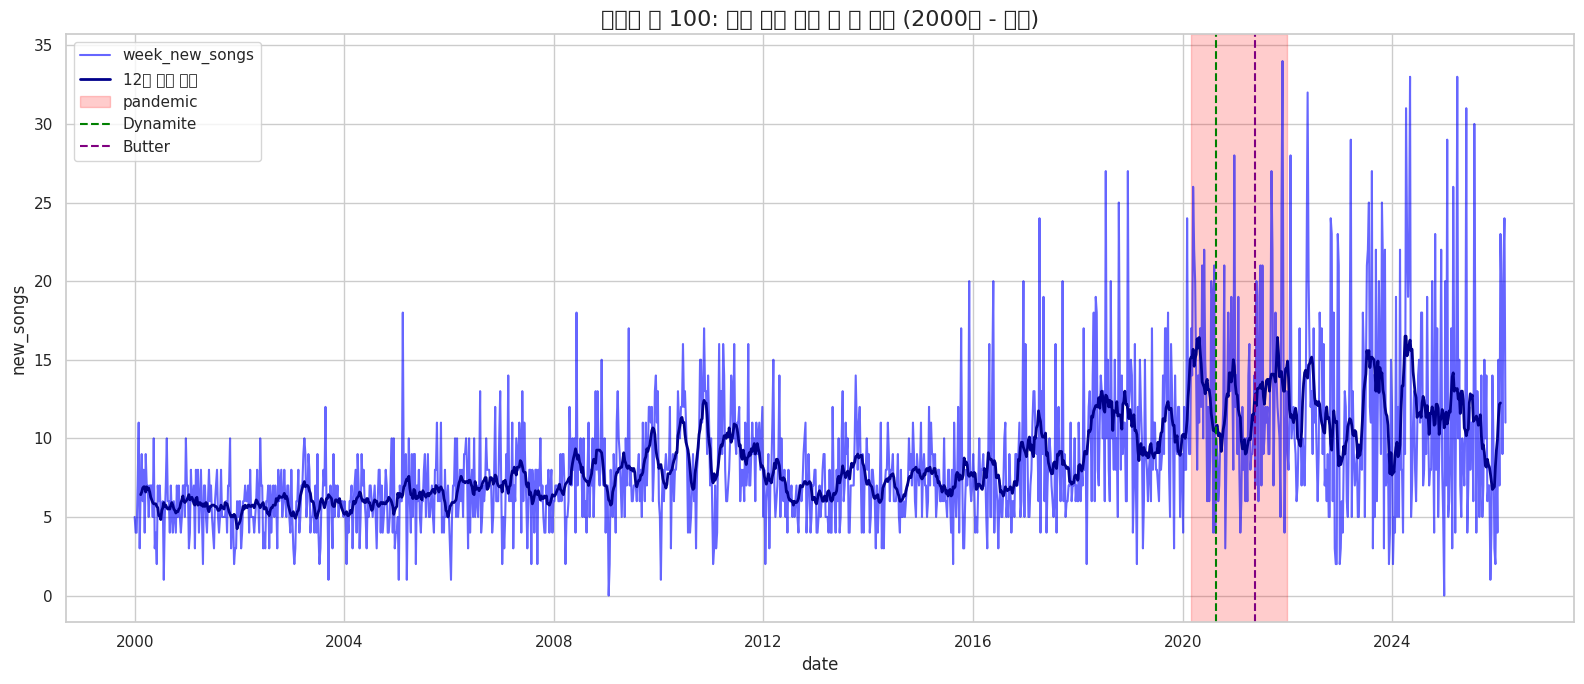

In [14]:
plt.figure(figsize=(16, 7))
sns.lineplot(data=weekly_new_entries, x='date', y='new_entries_count', alpha=0.6, color='blue', label='week_new_songs')

# 12주 이동 평균선으로 추이 부드럽게 만들기
weekly_new_entries['rolling_avg'] = weekly_new_entries['new_entries_count'].rolling(window=12, center=True).mean()
sns.lineplot(data=weekly_new_entries, x='date', y='rolling_avg', color='darkblue', linewidth=2, label='12주 이동 평균')

# 코로나19 팬데믹 시기 강조 (약 2020년 3월 ~ 2021년 12월)
plt.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2021-12-31'), color='red', alpha=0.2, label='pandemic')

# BTS의 "Dynamite" (2020년 8월)와 "Butter" (2021년 5월) 발매 시점 강조
plt.axvline(pd.to_datetime('2020-08-21'), color='green', linestyle='--', label="Dynamite")
plt.axvline(pd.to_datetime('2021-05-21'), color='purple', linestyle='--', label="Butter")

plt.title('빌보드 핫 100: 주간 신규 진입 곡 수 추이 (2000년 - 현재)', fontsize=16)
plt.xlabel('date')
plt.ylabel('new_songs')
plt.legend()
plt.tight_layout()
plt.show()


## 3. 노래 수명(차트 머문 기간) 분석

다음으로 각 노래별 전체 차트 진입 기간(주)을 계산합니다.

In [7]:
# 각 노래별 총 수명(차트에 머문 주 수) 계산
song_lifespans = df.groupby(['title', 'artist']).agg({
    'date': 'count', # 차트에 머문 주 수
    'peakpos': 'min', # 최고 순위(작을수록 높음)
    'is_kpop': 'max', # K-Pop 여부
    'entry_competition': 'max', # 진입 주차의 경쟁 강도
    'entry_date': 'min'
}).rename(columns={'date': 'total_weeks_charted'}).reset_index()

# 0주인 데이터 필터링 (예외 방지)
song_lifespans = song_lifespans[song_lifespans['total_weeks_charted'] > 0]

kpop_songs = song_lifespans[song_lifespans['is_kpop'] == True].copy()
non_kpop_songs = song_lifespans[song_lifespans['is_kpop'] == False].copy()

print(f"추적된 K-Pop 노래 수: {len(kpop_songs)}")
kpop_songs.sort_values(by='total_weeks_charted', ascending=False).head(10)


추적된 K-Pop 노래 수: 1702


,title,artist,total_weeks_charted,peakpos,is_kpop,entry_competition,entry_date
10890,Wake Me Up!,Avicii,54,4,True,6,2013-07-13
8386,Rock And A Hard Place,Bailey Zimmerman,54,10,True,9,2022-06-25
4852,I Remember Everything,Zach Bryan Featuring Kacey Musgraves,52,1,True,22,2023-09-09
8928,Sicko Mode,Travis Scott,52,1,True,20,2018-08-18
229,A Holly Jolly Christmas,Burl Ives,51,4,True,9,2017-01-07
4781,I Like It,"Cardi B, Bad Bunny & J Balvin",51,1,True,18,2018-04-21
3821,Good 4 U,Olivia Rodrigo,51,1,True,20,2021-05-29
6217,Love Lies,Khalid & Normani,51,9,True,2,2018-03-03
7703,Paralyzer,Finger Eleven,50,6,True,6,2007-06-23
2042,Congratulations,Post Malone Featuring Quavo,50,8,True,16,2016-12-31


### 방탄소년단(BTS) 기록 확인
방탄소년단의 곡들이 차트에서 얼마나 오래 머물렀는지, 그리고 진입 당시 경쟁 강도는 어땠는지 확인합니다.

In [8]:
bts_songs = kpop_songs[kpop_songs['artist'].str.contains('BTS', case=False, na=False)].sort_values(by='total_weeks_charted', ascending=False)
bts_songs[['title', 'entry_date', 'total_weeks_charted', 'peakpos', 'entry_competition']]


,title,entry_date,total_weeks_charted,peakpos,entry_competition
2827,Dynamite,2020-09-05,32,1,6
1578,Butter,2021-06-05,20,1,15
6938,My Universe,2021-10-09,17,1,18
6365,MIC Drop,2017-12-16,10,28,6
1412,Boy With Luv,2019-04-27,8,8,8
7787,Permission To Dance,2021-07-24,7,1,10
3106,Fake Love,2018-06-02,6,10,11
858,Bad Decisions,2022-08-20,5,10,15
2234,DNA,2017-10-07,4,67,5
5894,Life Goes On,2020-12-05,3,1,19


## 4. 통계적 상관관계 확인

톱 40 안에 들었던 히트곡들을 대상으로, "초기 진입 경쟁이 낮을수록 차트 수명이 긴가?"라는 가설을 확인합니다.

진입 시 경쟁 강도와 차트 수명 간의 상관계수 (전체 히트곡): -0.3273


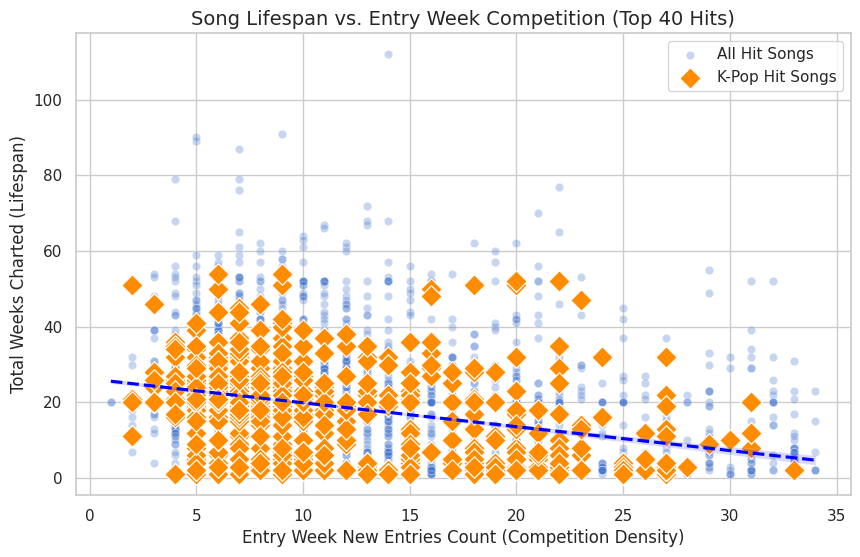

In [12]:
# 최고 순위 40위 이내의 히트곡들로 필터링
hits = song_lifespans[song_lifespans['peakpos'] <= 40]

correlation_all = hits['entry_competition'].corr(hits['total_weeks_charted'])
print(f"진입 시 경쟁 강도와 차트 수명 간의 상관계수 (전체 히트곡): {correlation_all:.4f}")

# 산점도 시각화
plt.figure(figsize=(10, 6))
sns.scatterplot(data=hits, x='entry_competition', y='total_weeks_charted', alpha=0.3, label='All Hit Songs')

# K-Pop 강조 표시
sns.scatterplot(data=kpop_songs[kpop_songs['peakpos']<=40], x='entry_competition', y='total_weeks_charted', color='darkorange', s=120, marker='D', label='K-Pop Hit Songs')

# 회귀선 추가
sns.regplot(data=hits, x='entry_competition', y='total_weeks_charted', scatter=False, color='blue', line_kws={"linestyle": "--"})

plt.title('Song Lifespan vs. Entry Week Competition (Top 40 Hits)', fontsize=14)
plt.xlabel('Entry Week New Entries Count (Competition Density)')
plt.ylabel('Total Weeks Charted (Lifespan)')
plt.legend()
plt.show()

## 5. 결론

코로나19 팬데믹 시기 경쟁 감소: 시계열 그래프를 통해 2020년 3월부터 2021년 12월까지의 코로나19 팬데믹 기간 동안 빌보드 핫 100 차트에 주간 신규 진입하는 곡의 수가 전반적으로 감소했음을 확인할 수 있었습니다. 이는 팬데믹이 음악 산업에 미친 영향 중 하나로 볼 수 있습니다.

K-Pop 노래의 차트 수명: K-Pop 아티스트들의 곡들은 차트에 진입 당시의 경쟁 강도와 무관하게 비교적 오랜 기간 차트에 머무는 경향을 보였습니다. 특히 방탄소년단(BTS)의 'Dynamite'와 'Butter'와 같은 곡들은 팬데믹 시기 낮은 경쟁 강도 속에서 높은 차트 순위와 함께 긴 차트 수명을 기록하며 K-Pop의 성공적인 사례를 보여주었습니다.

경쟁 강도와 차트 수명 간의 상관관계: 최고 순위 40위 이내의 히트곡들을 대상으로 분석한 결과, 진입 시 경쟁 강도와 차트 수명 간에 **약한 음의 상관관계(-0.3273)**가 있었습니다. 이는 경쟁이 치열할수록 곡의 차트 수명이 다소 짧아지는 경향이 있음을 시사하지만, 그 영향이 아주 크지는 않음을 의미합니다. 특히 K-Pop 곡들은 이러한 전반적인 경향에서 벗어나 높은 차트 수명을 유지하는 경우가 많았습니다.